# MHLA: Сравнение с другими attention



In [1]:
!pip install torch datasets matplotlib seaborn tqdm -q

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, math, time, warnings
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from collections import Counter

warnings.filterwarnings('ignore')
torch.manual_seed(42); np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
CFG = dict(
    d_model=128, num_heads=4, num_layers=3, max_len=256, num_classes=2, dropout=0.1,
    num_blocks=8, num_mixing_heads=4, vocab_size=10000, train_subset=6000,
    batch_size=32, lr=3e-4, epochs=15, warmup_steps=200, weight_decay=0.01, grad_clip=1.0,
)

## Данные: IMDb

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

IMDb: mean=226, median=171, max=1263


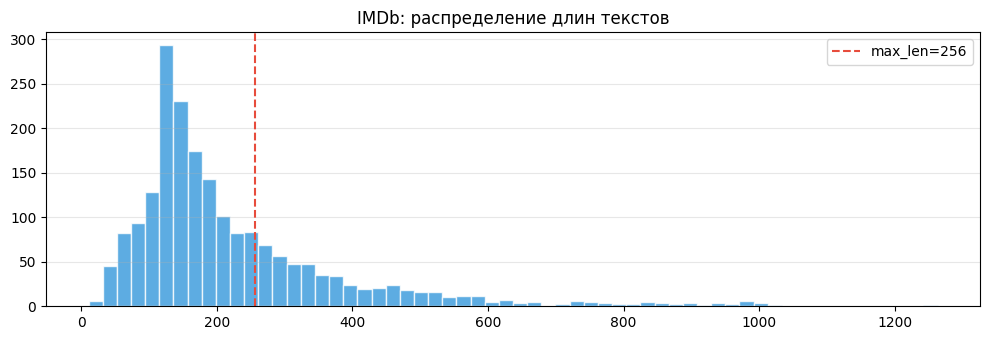

In [3]:
raw = load_dataset('imdb')
sample_texts = raw['train']['text'][:2000]
lengths = [len(t.split()) for t in sample_texts]
print(f"IMDb: mean={np.mean(lengths):.0f}, median={np.median(lengths):.0f}, max={np.max(lengths)}")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(lengths, bins=60, color='#3498db', alpha=0.8, edgecolor='white')
ax.axvline(CFG['max_len'], color='#e74c3c', linestyle='--', label=f'max_len={CFG["max_len"]}')
ax.set_title('IMDb: распределение длин текстов'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [6]:
def build_vocab(texts, max_vocab=10000, min_freq=3):
    counter = Counter(w for t in texts for w in t.lower().split())
    vocab = {t: i for i, t in enumerate(['<pad>', '<unk>', '<cls>'])}
    for word, freq in counter.most_common():
        if len(vocab) >= max_vocab: break
        if freq >= min_freq: vocab[word] = len(vocab)
    return vocab

def encode(text, vocab, max_len):
    tokens = ['<cls>'] + text.lower().split()
    ids = [vocab.get(t, vocab['<unk>']) for t in tokens][:max_len]
    pad = max_len - len(ids)
    return ids + [vocab['<pad>']] * pad, [1]*len(ids) + [0]*pad

vocab = build_vocab(raw['train']['text'], CFG['vocab_size'])

class IMDbDataset(Dataset):
    def __init__(self, data, vocab, max_len):
        self.data, self.vocab, self.max_len = data, vocab, max_len
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        ids, mask = encode(self.data[idx]['text'], self.vocab, self.max_len)
        return {'input_ids': torch.tensor(ids, dtype=torch.long), 
                'mask': torch.tensor(mask, dtype=torch.float),
                'label': torch.tensor(self.data[idx]['label'], dtype=torch.long)}

train_data = list(raw['train'].shuffle(seed=42).select(range(CFG['train_subset'])))
val_data = list(raw['test'].shuffle(seed=42).select(range(2000)))
train_loader = DataLoader(IMDbDataset(train_data, vocab, CFG['max_len']), batch_size=CFG['batch_size'], shuffle=True)
val_loader = DataLoader(IMDbDataset(val_data, vocab, CFG['max_len']), batch_size=CFG['batch_size'])

## Механизмы внимания

In [7]:
def apply_mask_before_phi(x_raw, mask):
    return x_raw + (1.0 - mask[:, None, :, None]) * (-1e9) if mask is not None else x_raw

def phi(x): return F.elu(x) + 1

class SoftmaxAttention(nn.Module):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__()
        self.H, self.Dh = num_heads, d_model // num_heads
        self.scale = math.sqrt(self.Dh)
        self.W_Q, self.W_K, self.W_V, self.W_O = [nn.Linear(d_model, d_model) for _ in range(4)]

    def _split(self, x): return x.reshape(x.shape[0], x.shape[1], self.H, self.Dh).permute(0, 2, 1, 3)

    def forward(self, x, mask=None, return_attn=False):
        B, N, d = x.shape
        Q, K, V = self._split(self.W_Q(x)), self._split(self.W_K(x)), self._split(self.W_V(x))
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if mask is not None: scores = scores.masked_fill(mask[:, None, None, :] == 0, -1e9)
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, V).permute(0, 2, 1, 3).reshape(B, N, d)
        return (self.W_O(out), attn) if return_attn else self.W_O(out)


class LinearAttention(nn.Module):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__()
        self.H, self.Dh = num_heads, d_model // num_heads
        self.W_Q, self.W_K, self.W_V, self.W_O = [nn.Linear(d_model, d_model) for _ in range(4)]

    def _split(self, x): return x.reshape(x.shape[0], x.shape[1], self.H, self.Dh).permute(0, 2, 1, 3)

    def forward(self, x, mask=None, return_attn=False):
        B, N, d = x.shape
        Q_raw, K_raw, V = self._split(self.W_Q(x)), self._split(self.W_K(x)), self._split(self.W_V(x))
        K_raw = apply_mask_before_phi(K_raw, mask)
        Q_phi, K_phi = phi(Q_raw), phi(K_raw)
        
        KV = torch.einsum('bhnd,bhnv->bhdv', K_phi, V)
        z = K_phi.sum(dim=2)
        num = torch.einsum('bhnd,bhdv->bhnv', Q_phi, KV)
        denom = torch.einsum('bhnd,bhd->bhn', Q_phi, z).clamp(1e-6).unsqueeze(-1)
        out = (num / denom).permute(0, 2, 1, 3).reshape(B, N, d)
        
        if return_attn:
            A = torch.einsum('bhnd,bhmd->bhnm', Q_phi, K_phi)
            A = A / A.sum(dim=-1, keepdim=True).clamp(1e-6)
            return self.W_O(out), A
        return self.W_O(out)


class MHLinearAttention(nn.Module):
    def __init__(self, d_model, num_heads, num_blocks=8, num_mixing_heads=4, **kwargs):
        super().__init__()
        self.H, self.Dh, self.M, self.P = num_heads, d_model // num_heads, num_blocks, num_mixing_heads
        self.W_Q, self.W_K, self.W_V, self.W_O = [nn.Linear(d_model, d_model) for _ in range(4)]
        self.raw_weights = nn.Parameter(torch.randn(num_mixing_heads, num_blocks) * 0.1)
        self.W_g = nn.Linear(d_model, num_mixing_heads)

    def _split(self, x): return x.reshape(x.shape[0], x.shape[1], self.H, self.Dh).permute(0, 2, 1, 3)

    def forward(self, x, mask=None, return_attn=False):
        B, N, d = x.shape; H, Dh, M, P = self.H, self.Dh, self.M, self.P
        Q_raw, K_raw, V = self._split(self.W_Q(x)), self._split(self.W_K(x)), self._split(self.W_V(x))
        K_raw = apply_mask_before_phi(K_raw, mask)
        K_phi, Q_phi = phi(K_raw), phi(Q_raw)

        pad = (M - N % M) % M
        if pad > 0:
            K_phi, V, Q_phi = [F.pad(t, (0,0,0,pad)) for t in (K_phi, V, Q_phi)]
        N2, bs = N + pad, (N + pad) // M

        Kb, Vb, Qb = [t.reshape(B, H, M, bs, Dh) for t in (K_phi, V, Q_phi)]
        S = torch.einsum('bhmsk,bhmsv->bhmkv', Kb, Vb)
        z = Kb.sum(dim=3)

        w = F.softmax(self.raw_weights, dim=-1)
        C = torch.einsum('pm,bhmkv->bhpkv', w, S)
        z_p = torch.einsum('pm,bhmk->bhpk', w, z)

        alpha = F.softmax(self.W_g(x), dim=-1)
        if pad > 0: alpha = F.pad(alpha, (0,0,0,pad))
        alpha_b = alpha.reshape(B, M, bs, P)

        C_b = torch.einsum('bmsp,bhpkv->bhmskv', alpha_b, C)
        z_b = torch.einsum('bmsp,bhpk->bhmsk', alpha_b, z_p)

        num = torch.einsum('bhmsd,bhmsde->bhmse', Qb, C_b)
        denom = torch.einsum('bhmsd,bhmsd->bhms', Qb, z_b).unsqueeze(-1).clamp(min=1e-6)
        out = (num / denom).reshape(B, H, N2, Dh)[:, :, :N].permute(0, 2, 1, 3).reshape(B, N, d)

        if return_attn:
            Q_f, K_f = Q_phi[:, :, :N], K_phi[:, :, :N]
            raw = torch.einsum('bhnd,bhmd->bhnm', Q_f, K_f)
            alpha_w = torch.einsum('bnp,pm->bnm', alpha[:, :N, :], w)
            block_j = torch.arange(N, device=x.device).div(bs, rounding_mode='floor').clamp(max=M-1)
            A = raw * alpha_w[:, :, block_j].unsqueeze(1)
            A = A / A.sum(dim=-1, keepdim=True).clamp(1e-6)
            return self.W_O(out), A
        return self.W_O(out)

## Модель классификатор


In [9]:
class TransformerLayer(nn.Module):
    def __init__(self, d_model, num_heads, attn_type='softmax', num_blocks=8, num_mixing_heads=4, dropout=0.1):
        super().__init__()
        attn_cls = {'softmax': SoftmaxAttention, 'linear': LinearAttention, 'mhla': MHLinearAttention}[attn_type]
        self.attn = attn_cls(d_model=d_model, num_heads=num_heads, num_blocks=num_blocks, num_mixing_heads=num_mixing_heads)
        self.norm1, self.norm2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.drop1, self.drop2 = nn.Dropout(dropout), nn.Dropout(dropout)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_model*4), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model*4, d_model))

    def forward(self, x, mask=None, return_attn=False):
        attn_out = self.attn(self.norm1(x), mask, return_attn=return_attn)
        A = None
        if return_attn: attn_out, A = attn_out
        x = x + self.drop1(attn_out)
        if mask is not None: x = x * mask.unsqueeze(-1)
        x = x + self.drop2(self.ffn(self.norm2(x)))
        if mask is not None: x = x * mask.unsqueeze(-1)
        return (x, A) if return_attn else x

class TextClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model, num_heads, num_layers, max_len, attn_type='softmax', num_blocks=8, num_mixing_heads=4, dropout=0.1):
        super().__init__()
        self.tok_emb, self.pos_emb = nn.Embedding(vocab_size, d_model, padding_idx=0), nn.Embedding(max_len, d_model)
        self.emb_drop = nn.Dropout(dropout)
        self.layers = nn.ModuleList([TransformerLayer(d_model, num_heads, attn_type, num_blocks, num_mixing_heads, dropout) for _ in range(num_layers)])
        self.norm, self.head = nn.LayerNorm(d_model), nn.Linear(d_model, num_classes)

    def forward(self, input_ids, mask=None, return_attn=False):
        B, N = input_ids.shape
        x = self.emb_drop(self.tok_emb(input_ids) + self.pos_emb(torch.arange(N, device=input_ids.device).unsqueeze(0)))
        attn_maps = []
        for layer in self.layers:
            res = layer(x, mask, return_attn=return_attn)
            if return_attn: x, A = res; attn_maps.append(A)
            else: x = res
        logits = self.head(self.norm(x)[:, 0])
        return (logits, attn_maps) if return_attn else logits

## Цикл обучения


In [10]:
def make_scheduler(opt, warmup, total):
    return torch.optim.lr_scheduler.LambdaLR(opt, lambda s: s/max(1,warmup) if s<warmup else max(0.0, 0.5*(1+math.cos(math.pi*(s-warmup)/max(1,total-warmup)))))

def run_epoch(model, loader, opt, sched, device, train=True):
    model.train() if train else model.eval()
    crit = nn.CrossEntropyLoss()
    t_loss = t_corr = t_tot = 0
    with torch.set_grad_enabled(train):
        for b in loader:
            ids, mask, labs = b['input_ids'].to(device), b['mask'].to(device), b['label'].to(device)
            logits = model(ids, mask)
            loss = crit(logits, labs)
            if train:
                opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip']); opt.step(); sched.step()
            t_loss += loss.item()*len(labs); t_corr += (logits.argmax(-1)==labs).sum().item(); t_tot += len(labs)
    return t_loss/t_tot, t_corr/t_tot

def run_experiment(attn_type, cfg, train_loader, val_loader, device):
    model = TextClassifier(len(vocab), cfg['num_classes'], cfg['d_model'], cfg['num_heads'], cfg['num_layers'], cfg['max_len'], attn_type, cfg['num_blocks'], cfg['num_mixing_heads'], cfg['dropout']).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sched = make_scheduler(opt, cfg['warmup_steps'], len(train_loader)*cfg['epochs'])
    hist, best_acc, best_state, t0 = dict(train_loss=[], train_acc=[], val_loss=[], val_acc=[]), 0.0, None, time.time()
    
    for ep in range(cfg['epochs']):
        tr_loss, tr_acc = run_epoch(model, train_loader, opt, sched, device, train=True)
        vl_loss, vl_acc = run_epoch(model, val_loader, opt, sched, device, train=False)
        for k, v in zip(['train_loss','train_acc','val_loss','val_acc'], [tr_loss,tr_acc,vl_loss,vl_acc]): hist[k].append(v)
        if vl_acc > best_acc: best_acc, best_state = vl_acc, {k: v.clone() for k, v in model.state_dict().items()}
        print(f'[{attn_type.upper():6s}] Ep {ep+1:2d}/{cfg["epochs"]} | tr_acc={tr_acc:.3f} vl_acc={vl_acc:.3f}')
    
    model.load_state_dict(best_state)
    return model, hist, best_acc, time.time()-t0

In [12]:
ATTN_TYPES = ['softmax', 'linear', 'mhla']
LABELS = {'softmax': 'Softmax', 'linear': 'Linear', 'mhla': 'MHLA'}
COLORS = {'softmax': '#e74c3c', 'linear': '#3498db', 'mhla': '#2ecc71'}
results, models = {}, {}

for attn_type in ATTN_TYPES:
    print(f"\n{LABELS[attn_type]}")
    model, history, best_acc, elapsed = run_experiment(attn_type, CFG, train_loader, val_loader, device)
    results[attn_type], models[attn_type] = dict(history=history, best_acc=best_acc, elapsed=elapsed), model
    print(f'Best val acc: {best_acc:.4f}, Time: {elapsed:.1f}s')


Softmax
[SOFTMAX] Ep  1/15 | tr_acc=0.509 vl_acc=0.536
[SOFTMAX] Ep  2/15 | tr_acc=0.651 vl_acc=0.704
[SOFTMAX] Ep  3/15 | tr_acc=0.741 vl_acc=0.721
[SOFTMAX] Ep  4/15 | tr_acc=0.784 vl_acc=0.756
[SOFTMAX] Ep  5/15 | tr_acc=0.817 vl_acc=0.762
[SOFTMAX] Ep  6/15 | tr_acc=0.828 vl_acc=0.755
[SOFTMAX] Ep  7/15 | tr_acc=0.853 vl_acc=0.768
[SOFTMAX] Ep  8/15 | tr_acc=0.872 vl_acc=0.763
[SOFTMAX] Ep  9/15 | tr_acc=0.886 vl_acc=0.765
[SOFTMAX] Ep 10/15 | tr_acc=0.902 vl_acc=0.765
[SOFTMAX] Ep 11/15 | tr_acc=0.911 vl_acc=0.762
[SOFTMAX] Ep 12/15 | tr_acc=0.915 vl_acc=0.761
[SOFTMAX] Ep 13/15 | tr_acc=0.921 vl_acc=0.758
[SOFTMAX] Ep 14/15 | tr_acc=0.919 vl_acc=0.762
[SOFTMAX] Ep 15/15 | tr_acc=0.924 vl_acc=0.759
Best val acc: 0.7680, Time: 106.3s

Linear
[LINEAR] Ep  1/15 | tr_acc=0.523 vl_acc=0.512
[LINEAR] Ep  2/15 | tr_acc=0.638 vl_acc=0.671
[LINEAR] Ep  3/15 | tr_acc=0.725 vl_acc=0.733
[LINEAR] Ep  4/15 | tr_acc=0.760 vl_acc=0.758
[LINEAR] Ep  5/15 | tr_acc=0.791 vl_acc=0.763
[LINEAR] Ep  

## Кривые обучения


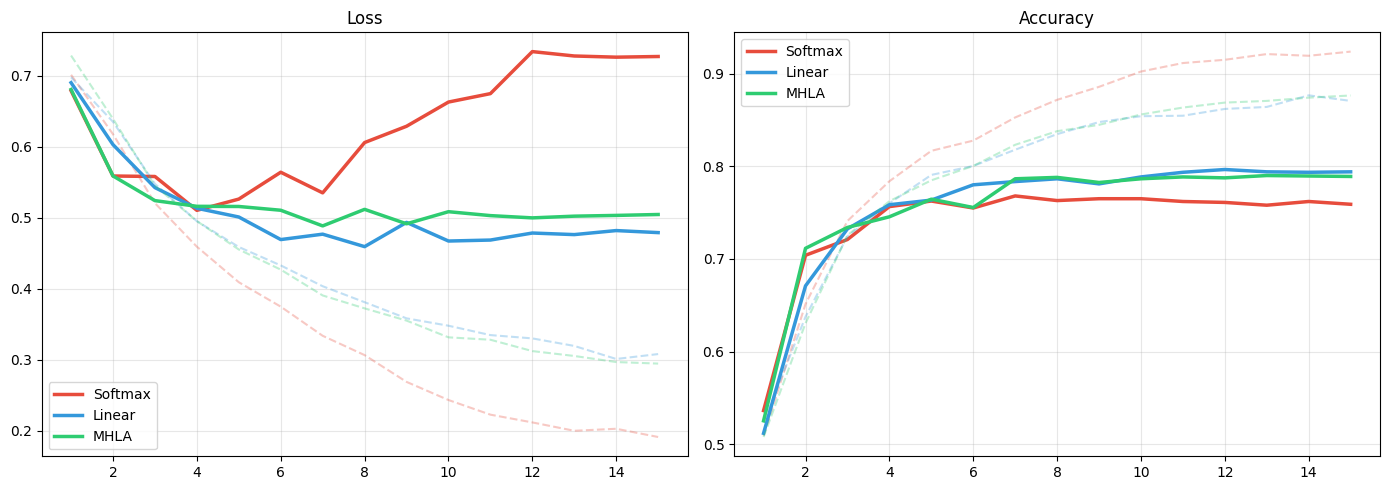

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = list(range(1, CFG['epochs'] + 1))
for ax, k1, k2, ttl in zip(axes, ['train_loss','train_acc'], ['val_loss','val_acc'], ['Loss','Accuracy']):
    for at in ATTN_TYPES:
        h = results[at]['history']
        ax.plot(epochs, h[k1], color=COLORS[at], alpha=0.3, linestyle='--')
        ax.plot(epochs, h[k2], color=COLORS[at], linewidth=2.5, label=LABELS[at])
    ax.set_title(ttl); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Анализ матриц внимания (Ранг и Энтропия)


Softmax : rank=137.1±46.5, entropy=4.930±0.481
Linear  : rank=31.5±1.6, entropy=4.906±0.461
MHLA    : rank=34.3±2.2, entropy=4.965±0.466


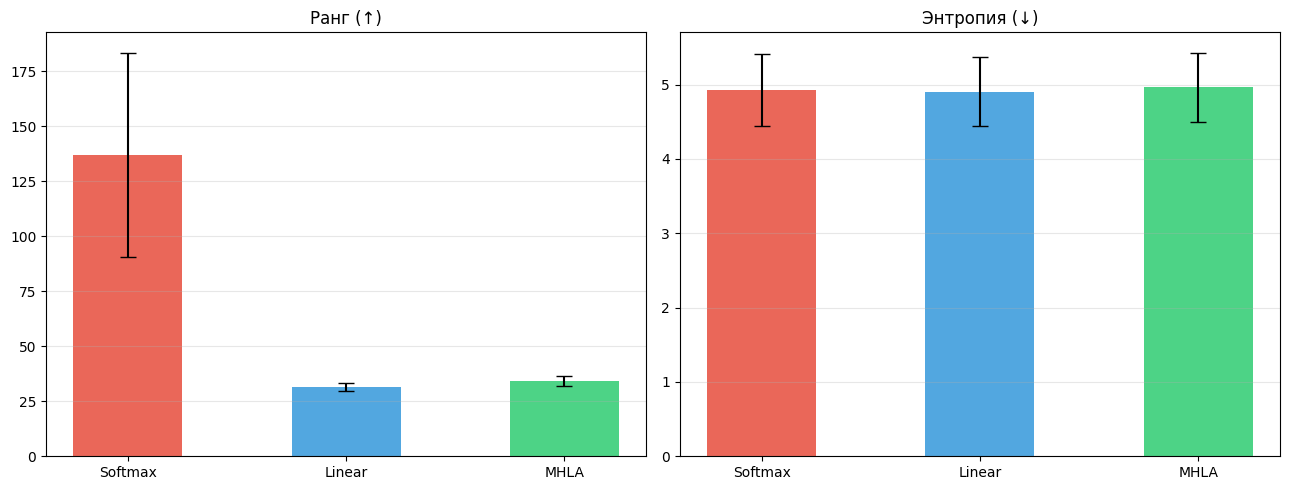

In [14]:
@torch.no_grad()
def compute_attn_stats(model, loader, device, n_batches=10):
    model.eval(); ranks, entropies = [], []
    for i, b in enumerate(loader):
        if i >= n_batches: break
        _, attn_list = model(b['input_ids'].to(device), b['mask'].to(device), return_attn=True)
        A = attn_list[-1].float().cpu().numpy()
        for bi in range(A.shape[0]):
            for hi in range(A.shape[1]):
                ranks.append(np.linalg.matrix_rank(A[bi, hi], tol=1e-3))
        entropies.extend((-np.sum(np.clip(A, 1e-9,1.0) * np.log(np.clip(A, 1e-9,1.0)), axis=-1)).flatten().tolist())
    return np.mean(ranks), np.std(ranks), np.mean(entropies), np.std(entropies)

attn_stats, Dh = {}, CFG['d_model'] // CFG['num_heads']
for at, model in models.items():
    r_mu, r_std, e_mu, e_std = compute_attn_stats(model, val_loader, device)
    attn_stats[at] = dict(rank_mu=r_mu, rank_std=r_std, ent_mu=e_mu, ent_std=e_std)
    print(f'{LABELS[at]:<8}: rank={r_mu:.1f}±{r_std:.1f}, entropy={e_mu:.3f}±{e_std:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(ATTN_TYPES))
for ax, key, ttl, comp in zip(axes, ['rank_mu', 'ent_mu'], ['Ранг (↑)', 'Энтропия (↓)'], [None, None]):
    vals = [attn_stats[k][key] for k in ATTN_TYPES]
    errs = [attn_stats[k]['rank_std'] if key=='rank_mu' else attn_stats[k]['ent_std'] for k in ATTN_TYPES]
    ax.bar(x, vals, 0.5, yerr=errs, capsize=6, color=[COLORS[k] for k in ATTN_TYPES], alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([LABELS[k] for k in ATTN_TYPES]); ax.set_title(ttl); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Тепловые карты внимания


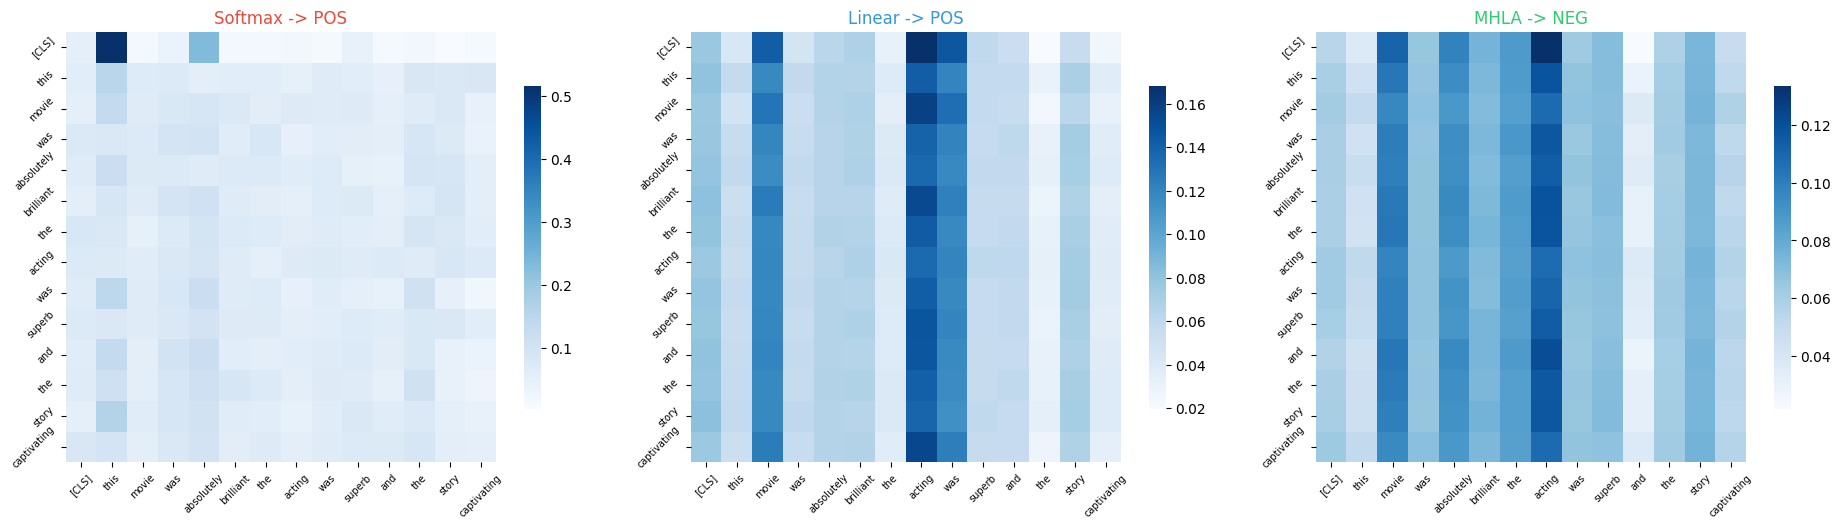

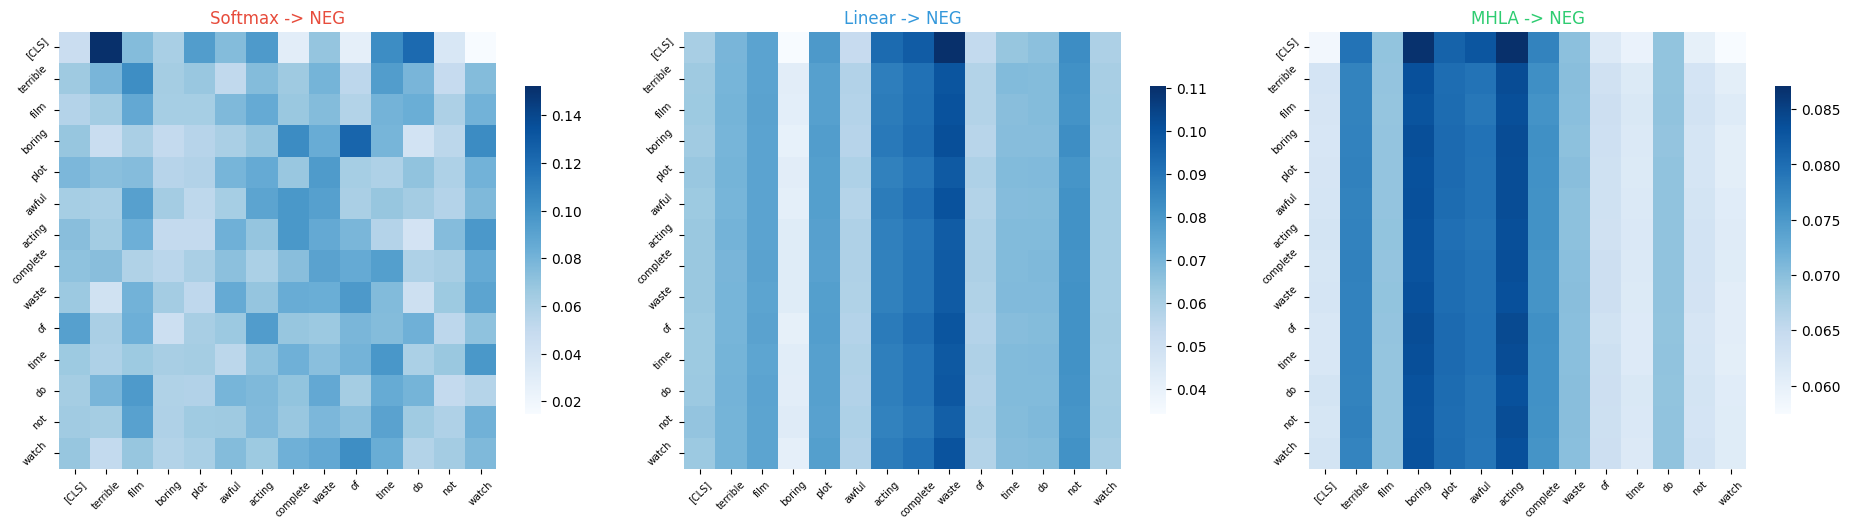

In [15]:
@torch.no_grad()
def get_attn_map(model, sentence, vocab, device):
    ids, mask = encode(sentence, vocab, CFG['max_len'])
    logits, attn_list = model(torch.tensor([ids]).to(device), torch.tensor([mask]).to(device), return_attn=True)
    A = attn_list[-1][0].mean(0).cpu().numpy()
    tokens = ['[CLS]'] + sentence.lower().split()
    n = min(len(tokens), 24)
    return A[:n, :n], tokens[:n], logits.argmax(-1).item()

for sent in ["this movie was absolutely brilliant the acting was superb and the story captivating",
             "terrible film boring plot awful acting complete waste of time do not watch"]:
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    for ax, at in zip(axes, ATTN_TYPES):
        A, tokens, pred = get_attn_map(models[at], sent, vocab, device)
        sns.heatmap(A, ax=ax, xticklabels=tokens, yticklabels=tokens, cmap='Blues', square=True, cbar_kws={'shrink':0.75})
        ax.set_title(f'{LABELS[at]} -> {"POS" if pred==1 else "NEG"}', color=COLORS[at]); ax.tick_params(rotation=45, labelsize=7)
    plt.tight_layout(); plt.show()

# Анализ компонентов MHLA


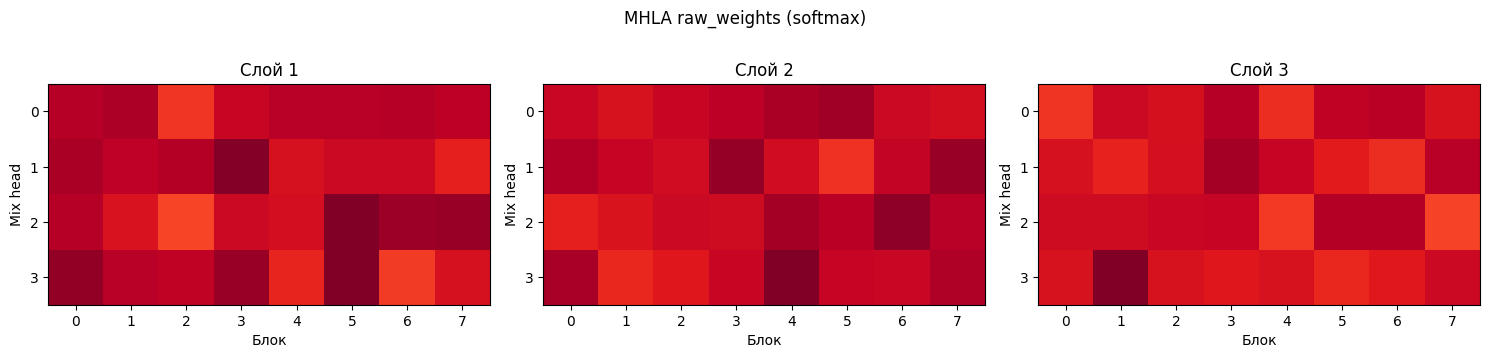

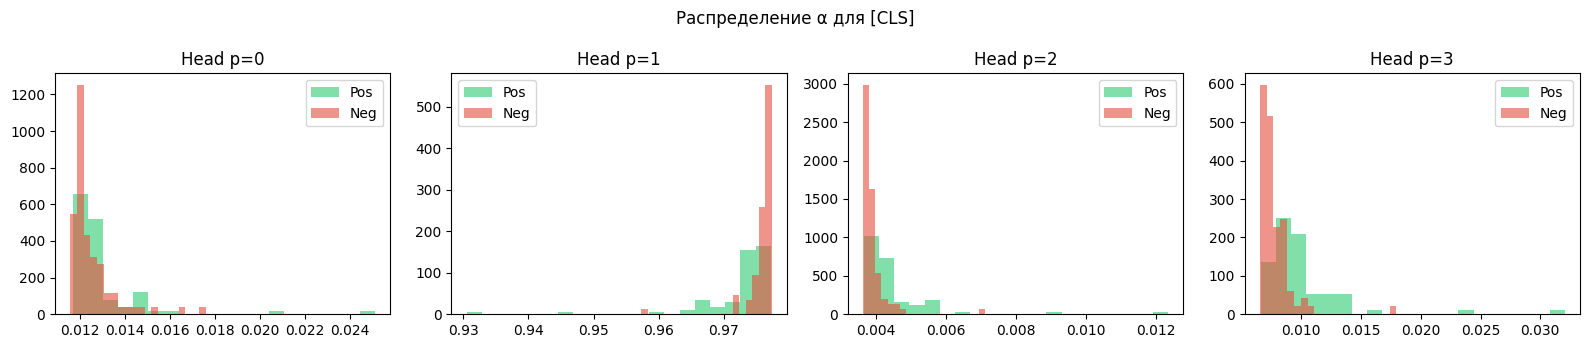

In [16]:
mhla_model = models['mhla']
fig, axes = plt.subplots(1, CFG['num_layers'], figsize=(5*CFG['num_layers'], 3.5))
if CFG['num_layers'] == 1: axes = [axes]
for i, (ax, layer) in enumerate(zip(axes, mhla_model.layers)):
    w = F.softmax(layer.attn.raw_weights, dim=-1).detach().cpu().numpy()
    ax.imshow(w, cmap='YlOrRd', vmin=0, vmax=w.max()); ax.set_title(f'Слой {i+1}'); ax.set_xlabel('Блок'); ax.set_ylabel('Mix head')
plt.suptitle('MHLA raw_weights (softmax)'); plt.tight_layout(); plt.show()

@torch.no_grad()
def get_alpha_dist(model, loader, device, n_batches=5):
    model.eval(); alphas_pos, alphas_neg = [], []
    for i, b in enumerate(loader):
        if i >= n_batches: break
        ids, mask, labels = b['input_ids'].to(device), b['mask'].to(device), b['label']
        pos = torch.arange(ids.size(1), device=device).unsqueeze(0)
        x = model.emb_drop(model.tok_emb(ids) + model.pos_emb(pos))
        for layer in model.layers[:-1]: x = layer(x, mask)
        alpha = F.softmax(model.layers[-1].attn.W_g(model.layers[-1].norm1(x)), dim=-1)[:, 0].cpu().numpy()
        for bi in range(ids.size(0)):
            (alphas_pos if labels[bi]==1 else alphas_neg).append(alpha[bi])
    return np.array(alphas_pos), np.array(alphas_neg)

alphas_pos, alphas_neg = get_alpha_dist(mhla_model, val_loader, device)
fig, axes = plt.subplots(1, CFG['num_mixing_heads'], figsize=(4*CFG['num_mixing_heads'], 3.5))
if CFG['num_mixing_heads'] == 1: axes = [axes]
for p, ax in enumerate(axes):
    ax.hist(alphas_pos[:, p], bins=20, alpha=0.6, color='#2ecc71', label='Pos', density=True)
    ax.hist(alphas_neg[:, p], bins=20, alpha=0.6, color='#e74c3c', label='Neg', density=True)
    ax.set_title(f'Head p={p}'); ax.legend()
plt.suptitle('Распределение α для [CLS]'); plt.tight_layout(); plt.show()

# производительность


seq_len=64
  Softmax :   15962 s/s
  Linear  :   13389 s/s
  MHLA    :    9660 s/s
seq_len=128
  Softmax :   15523 s/s
  Linear  :   12759 s/s
  MHLA    :    9558 s/s
seq_len=256
  Softmax :    7380 s/s
  Linear  :   12048 s/s
  MHLA    :    6110 s/s
seq_len=512
  Softmax :    2907 s/s
  Linear  :    5966 s/s
  MHLA    :    3093 s/s
seq_len=1024
  Softmax :     882 s/s
  Linear  :    3112 s/s
  MHLA    :    1587 s/s


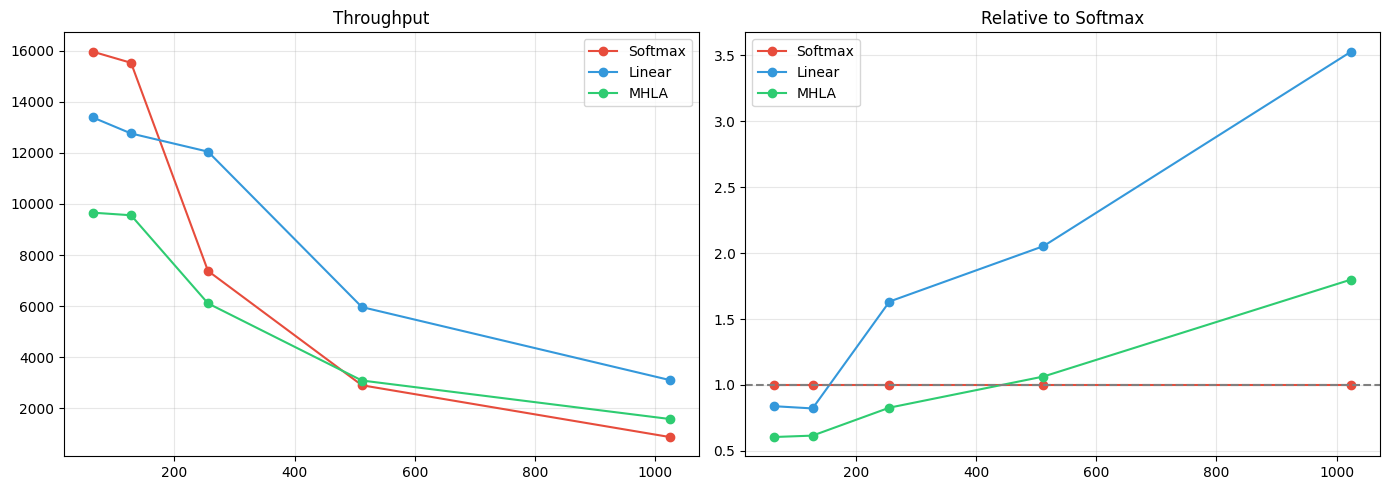

In [17]:
# Бенчмарк производительности
@torch.no_grad()
def throughput(model, device, seq_len, batch_size=16, n_runs=30):
    model.eval(); ids = torch.randint(4, len(vocab), (batch_size, seq_len)).to(device); mask = torch.ones(batch_size, seq_len).to(device)
    for _ in range(5): model(ids, mask)
    if device.type=='cuda': torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n_runs): model(ids, mask)
    if device.type=='cuda': torch.cuda.synchronize()
    return (n_runs*batch_size)/(time.time()-t0)

seq_lengths = [64, 128, 256, 512, 1024]; speed_res = {k:[] for k in ATTN_TYPES}
bench_models = {at: TextClassifier(len(vocab), 2, 128, 4, 1, max(seq_lengths), at, 8, 4).to(device) for at in ATTN_TYPES}

for sl in seq_lengths:
    print(f'seq_len={sl}')
    for at, bm in bench_models.items():
        try: sps = throughput(bm, device, sl)
        except: sps = float('nan')
        speed_res[at].append(sps)
        print(f"  {LABELS[at]:<8}: {sps:7.0f} s/s")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for at in ATTN_TYPES: axes[0].plot(seq_lengths, speed_res[at], marker='o', color=COLORS[at], label=LABELS[at])
axes[0].set_title('Throughput'); axes[0].legend(); axes[0].grid(alpha=0.3)
for at in ATTN_TYPES: axes[1].plot(seq_lengths, np.array(speed_res[at])/np.array(speed_res['softmax']), marker='o', color=COLORS[at], label=LABELS[at])
axes[1].axhline(1.0, color='gray', linestyle='--'); axes[1].set_title('Relative to Softmax'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


════════════════════════════════════════════════════════════
                    ИТОГ: IMDb Sentiment                    
____________________________________________________________
Softmax  | Acc: 0.7680 | Rank: 137.1 | Ent: 4.930 | 106.3s
Linear   | Acc: 0.7965 | Rank: 31.5 | Ent: 4.906 | 78.8s
MHLA     | Acc: 0.7900 | Rank: 34.3 | Ent: 4.965 | 156.5s
════════════════════════════════════════════════════════════


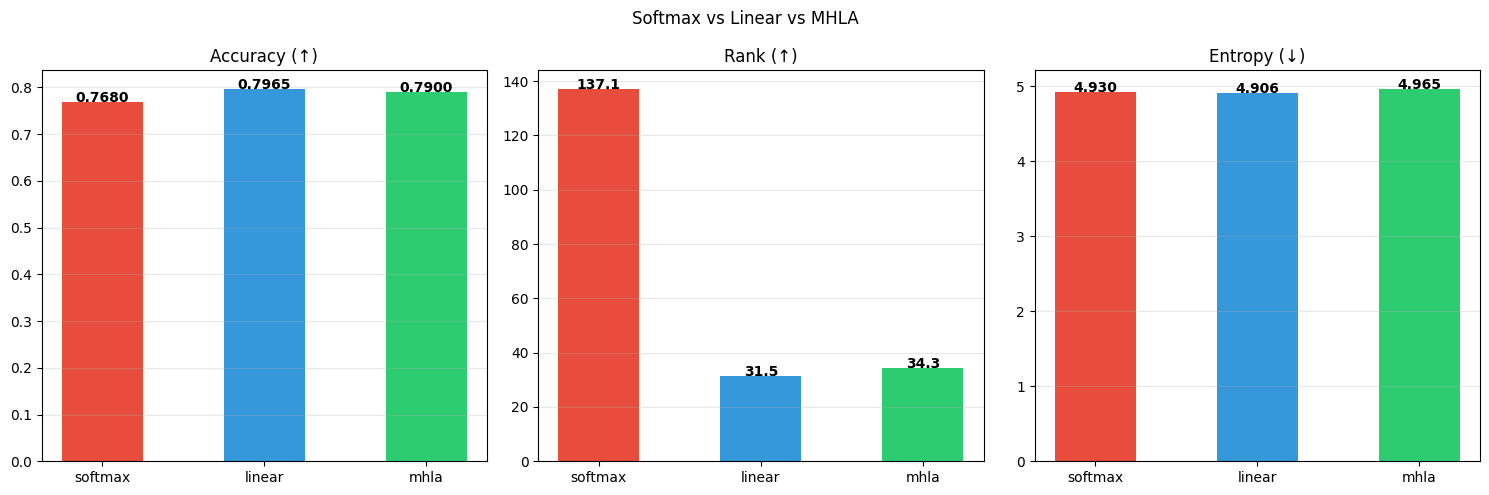

In [19]:
# Итоги
print('\n' + '═'*60)
print(f'{"ИТОГ: IMDb Sentiment":^60}')
print('_'*60)
for at in ATTN_TYPES:
    r = results[at]; s = attn_stats[at]
    print(f'{LABELS[at]:<8} | Acc: {r["best_acc"]:.4f} | Rank: {s["rank_mu"]:.1f} | Ent: {s["ent_mu"]:.3f} | {r["elapsed"]:.1f}s')
print('═'*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, get_val, fmt, ttl in zip(axes, 
    [lambda k: results[k]['best_acc'], lambda k: attn_stats[k]['rank_mu'], lambda k: attn_stats[k]['ent_mu']],
    ['{:.4f}', '{:.1f}', '{:.3f}'], ['Accuracy (↑)', 'Rank (↑)', 'Entropy (↓)']):
    vals = [get_val(k) for k in ATTN_TYPES]
    bars = ax.bar(ATTN_TYPES, vals, 0.5, color=[COLORS[k] for k in ATTN_TYPES])
    for bar, val in zip(bars, vals): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), fmt.format(val), ha='center', fontweight='bold')
    ax.set_title(ttl); ax.grid(axis='y', alpha=0.3)
plt.suptitle('Softmax vs Linear vs MHLA'); plt.tight_layout(); plt.show()

# Выводы

**1. Выразительность и ранг**
Гипотеза статьи подтвердилась: классический Linear Attention уперся в теоретический потолок ранга ($D_h = 32$), показав 31.5. Механизм **MHLA** превзошел лимит(ранг 34.3). Хотя на нашей маленькой модели ($d\_model=128$) разрыв невелик, все равно наблюдаем, что MHLA восстанавливает потерянны ранг матрицы.

**2. Качество**
Оба линейных метода (Linear — 79.6%, MHLA — 79.0%) обошли стандартный Softmax (76.8%). Вероятнее всего, Softmax быстрее переобучился на небольшой выборке (6000 примеров), тогда как линейные методы за счет "сжатия" контекста сработали как хорошая регуляризация.

**3. Масштабирование и скорость (Throughput)**
* **На коротких текстах ($N \le 256$)**: Стандартный Softmax выигрывает. MHLA уступает даже ванильному Linear.
* **На длинных текстах ($N = 1024$ и выше)**: Скорость Softmax катастрофически падает (до 882 s/s), тогда как **MHLA становится почти в 2 раза быстрее Softmax** (1587 s/s).

**Общий итог:**
MHLA на данном пример работает ровно так, как заявлено:**сохраняет линейную вычислительную сложность** на длинных текстах и помогает в решении **проблемы коллапса ранга**, присущую стандартному линейному вниманию. Но из-за накладных расходов на вычисление блоков (M) и смесей (P), использовать MHLA лучше  **на задачах с длинным контекстом (от 512–1024 токенов)**, где классический Softmax начинает работать дольше.